<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Assignment 5</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Data Science <br><br>
        <b>🧑‍💻 Implementer:</b> Parsa Saeednia <br>
        <b>🆔 Student ID:</b> 810102460 <br><br>
        <h5 style="color: #1a365d;"> TASK 2 Implementation</h5>
    </p>
</div>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
    This notebook contains the programmatic implementation for Assignment 5 - Task 2. It focuses on evaluating semantic equivalence between formal and informal Persian sentences using the ParsMap dataset. The implementation covers training custom Word2Vec models, extracting contextual representations via ParsBERT, visualizing embedding alignments using non-linear dimensionality reduction, and training a binary classifier to detect semantic similarity.
</div>

## Table of Contents
1. [Dataset Loading & Word2Vec Static Embedding Training](#word2vec-training)
2. [ParsBERT Contextual Embeddings & Sentence Representation](#parsbert-embeddings)
3. [Dimensionality Reduction (PCA, t-SNE/UMAP) & Alignment Visualization](#visualization)
4. [Balanced Binary Dataset Creation & Classification Pipeline](#classification)
5. [Comparative Analysis (Word2Vec vs. ParsBERT)](#evaluation)

<a id="word2vec-training"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">1. Dataset Loading & Word2Vec Static Embedding Training</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #bd9f72; color: #4b3a1f;">
    <strong>📜 Methodology:</strong>
    We load the Persian ParsMap dataset and clean the formal and informal text fields. A static vector space is constructed by training a custom <code>Word2Vec</code> model using the <code>gensim</code> library (comparing CBOW and Skip-Gram configurations). Semantic representation quality is evaluated by extracting cosine similarities for nearest-neighbor words.
</div>


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

def load_and_explore_data(file_path):
    df = pd.read_excel(file_path)
    
    if not {'formalForm', 'inFormalForm'}.issubset(df.columns):
        raise ValueError(f"Dataset columns found: {list(df.columns)}. Must contain 'formalForm' and 'inFormalForm'.")
        
    print(f"Total sentence pairs in the dataset: {len(df)}\n")
    
    sample_df = df.sample(n=5, random_state=42)
    
    for index, row in sample_df.iterrows():
        print(f"--- Pair {index} ---")
        print(f"Formal:   {row['formalForm']}")
        print(f"Informal: {row['inFormalForm']}\n")
        
    return df

df = load_and_explore_data('data/trainset_40k_onlySent.xlsx')

Total sentence pairs in the dataset: 40018

--- Pair 22949 ---
Formal:   همسر من نه اخلاق دارد، نه صله‌رحم دارد و نه احساس دارد و خیلی کم پیش می‌آید که در خانۀ من مهمان بیاید و من واقعاً دلم می‌گیرد.
Informal: همسر من نه اخلاق داره ن صله رحم داره ن احساس داره و توخونه من خیلی کم پیش میاد مهمون بیاد ومن واقعا دلم میگیره.

--- Pair 22690 ---
Formal:   با صدای در، هر دوی ما متعجب به طرف در برگشتیم.
Informal: با صدای در هر دوتامون متعجب برگشتیم طرف در

--- Pair 2299 ---
Formal:   وقتی سینا هم ببیند نرفته‌ام ول می‌کند و می‌رود.
Informal: سینا هم وقتی ببینه نرفتم ول میکنه و میره

--- Pair 8671 ---
Formal:   یعنی حتماً باید به دوا و درمان متوسل بشوم؟
Informal: یعنی حتما باید متوسل به دوادرمون بشم؟

--- Pair 29288 ---
Formal:   دلم می‌خواهد سرم را روی شانه‌ات بگذارم، روی سینه‌ات، روی زانویت، چه می‌دانم دیگر پیش تو باشم و زارزار مثل باران گریه کنم.
Informal: دلم میخواد سرمو بذارم روی شونت، روی سـینت، روی زانـوت چـه میـدونم پیشت باشم دیگه و زار زار گریه کنم مثل بارون



=================== Sentence Length Statistics ===================
                      mean    std  min  median    max
formal_word_count    12.34   6.50  1.0    11.0   67.0
informal_word_count  11.39   6.53  1.0    10.0   64.0
formal_char_count    62.62  31.99  9.0    56.0  322.0
informal_char_count  55.08  30.05  5.0    48.0  320.0



C:\Users\HMazaheri\AppData\Local\Temp\ipykernel_9440\2069098391.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 0].set_xticklabels(['Formal', 'Informal'])
C:\Users\HMazaheri\AppData\Local\Temp\ipykernel_9440\2069098391.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 1].set_xticklabels(['Formal', 'Informal'])


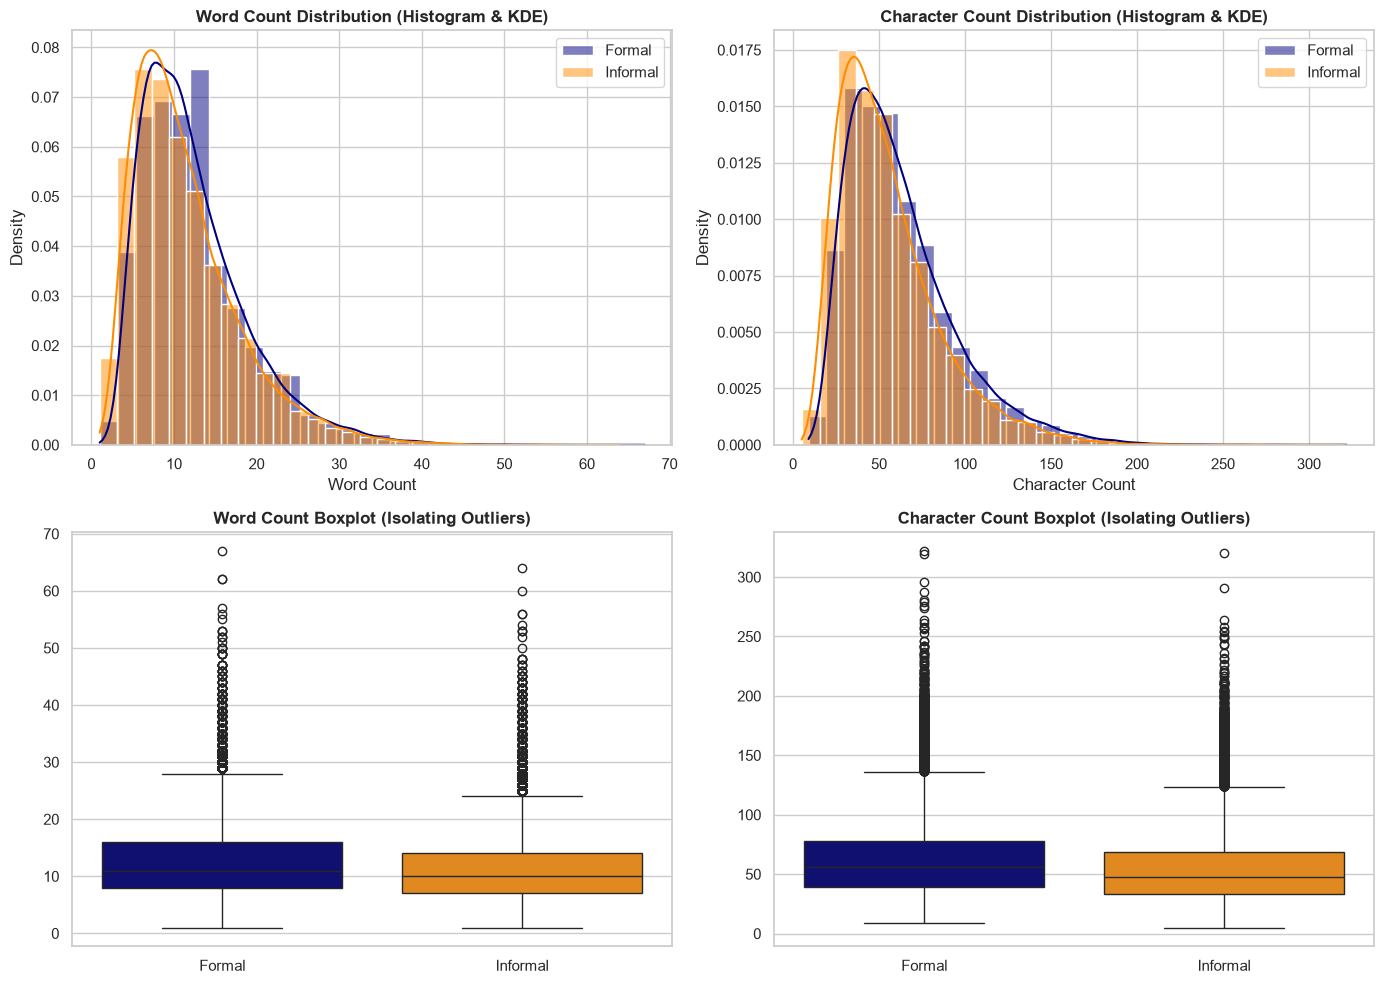

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set aesthetic styling for data analysis plots
sns.set_theme(style="whitegrid")

def analyze_sentence_lengths(df):
    df['formal_word_count'] = df['formalForm'].astype(str).apply(lambda x: len(x.split()))
    df['informal_word_count'] = df['inFormalForm'].astype(str).apply(lambda x: len(x.split()))
    df['formal_char_count'] = df['formalForm'].astype(str).apply(len)
    df['informal_char_count'] = df['inFormalForm'].astype(str).apply(len)
    
    cols = ['formal_word_count', 'informal_word_count', 'formal_char_count', 'informal_char_count']
    summary_stats = df[cols].describe().T[['mean', 'std', 'min', '50%', 'max']]
    summary_stats.rename(columns={'50%': 'median'}, inplace=True)
    
    print("=================== Sentence Length Statistics ===================")
    print(summary_stats.round(2))
    print("=================================================================\n")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sns.histplot(df['formal_word_count'], color='navy', label='Formal', kde=True, ax=axes[0, 0], stat='density', common_norm=False, bins=30)
    sns.histplot(df['informal_word_count'], color='darkorange', label='Informal', kde=True, ax=axes[0, 0], stat='density', common_norm=False, bins=30)
    axes[0, 0].set_title("Word Count Distribution (Histogram & KDE)", fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel("Word Count")
    axes[0, 0].legend()
    sns.histplot(df['formal_char_count'], color='navy', label='Formal', kde=True, ax=axes[0, 1], stat='density', common_norm=False, bins=30)
    sns.histplot(df['informal_char_count'], color='darkorange', label='Informal', kde=True, ax=axes[0, 1], stat='density', common_norm=False, bins=30)
    axes[0, 1].set_title("Character Count Distribution (Histogram & KDE)", fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel("Character Count")
    axes[0, 1].legend()
    sns.boxplot(data=df[['formal_word_count', 'informal_word_count']], palette=['navy', 'darkorange'], ax=axes[1, 0])
    axes[1, 0].set_title("Word Count Boxplot (Isolating Outliers)", fontsize=12, fontweight='bold')
    axes[1, 0].set_xticklabels(['Formal', 'Informal'])
    sns.boxplot(data=df[['formal_char_count', 'informal_char_count']], palette=['navy', 'darkorange'], ax=axes[1, 1])
    axes[1, 1].set_title("Character Count Boxplot (Isolating Outliers)", fontsize=12, fontweight='bold')
    axes[1, 1].set_xticklabels(['Formal', 'Informal'])
    
    plt.tight_layout()
    plt.show()
    
    return df

df = analyze_sentence_lengths(df)

=================== Vocabulary Statistics ===================
Total Formal Tokens:           561,248
Total Informal Tokens:         461,073
Formal Vocabulary Size:        25,800
Informal Vocabulary Size:      46,258
Unique to Formal Register:     10,718
Unique to Informal Register:   31,176



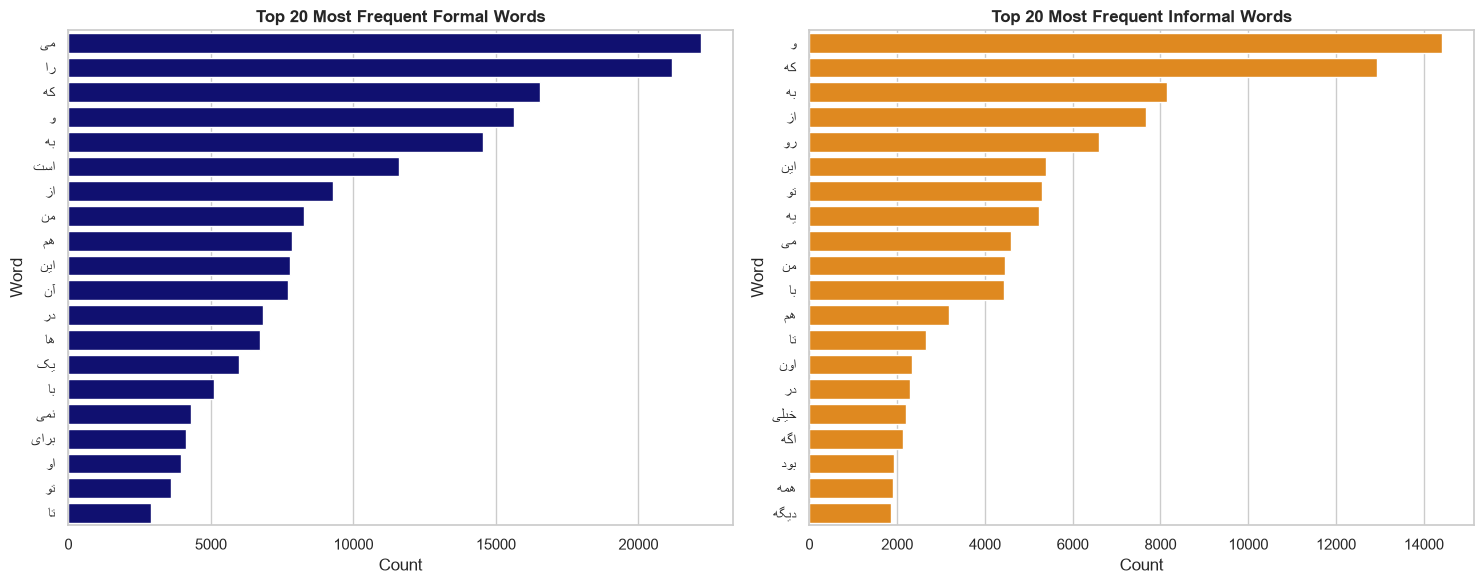

In [18]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

def analyze_vocabularies(df):
    """
    Builds formal and informal vocabularies, computes unique and top-20 terms,
    and visualizes top frequencies for each register.
    """
    # Simple regex word tokenizer (preserves Persian characters)
    def tokenize(text):
        return re.findall(r'[\w\u0600-\u06FF]+', str(text))
    
    # Generate token lists
    formal_tokens = [token for text in df['formalForm'] for token in tokenize(text)]
    informal_tokens = [token for text in df['inFormalForm'] for token in tokenize(text)]
    
    # Calculate token frequencies
    formal_counts = Counter(formal_tokens)
    informal_counts = Counter(informal_tokens)
    
    formal_vocab = set(formal_counts.keys())
    informal_vocab = set(informal_counts.keys())
    
    # Compute uniqueness
    unique_formal = formal_vocab - informal_vocab
    unique_informal = informal_vocab - formal_vocab
    
    print("=================== Vocabulary Statistics ===================")
    print(f"Total Formal Tokens:           {len(formal_tokens):,}")
    print(f"Total Informal Tokens:         {len(informal_tokens):,}")
    print(f"Formal Vocabulary Size:        {len(formal_vocab):,}")
    print(f"Informal Vocabulary Size:      {len(informal_vocab):,}")
    print(f"Unique to Formal Register:     {len(unique_formal):,}")
    print(f"Unique to Informal Register:   {len(unique_informal):,}")
    print("=============================================================\n")
    
    # Get Top 20 Most Frequent Terms
    top20_formal = pd.DataFrame(formal_counts.most_common(20), columns=['Word', 'Count'])
    top20_informal = pd.DataFrame(informal_counts.most_common(20), columns=['Word', 'Count'])
    
    # Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Top 20 Formal
    sns.barplot(data=top20_formal, x='Count', y='Word', color='navy', ax=axes[0])
    axes[0].set_title("Top 20 Most Frequent Formal Words", fontsize=12, fontweight='bold')
    
    # Top 20 Informal
    sns.barplot(data=top20_informal, x='Count', y='Word', color='darkorange', ax=axes[1])
    axes[1].set_title("Top 20 Most Frequent Informal Words", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'formal_vocab': formal_vocab,
        'informal_vocab': informal_vocab,
        'unique_formal': unique_formal,
        'unique_informal': unique_informal,
        'top20_formal': top20_formal,
        'top20_informal': top20_informal
    }

# Execute vocabulary analysis
vocab_results = analyze_vocabularies(df)

Loading tokenizer: HooshvareLab/bert-fa-base-uncased...

================ Subword Fragmentation Samples ================

--- Pair ID: 22949 ---
Formal Text:       همسر من نه اخلاق دارد، نه صله‌رحم دارد و نه احساس دارد و خیلی کم پیش می‌آید که در خانۀ من مهمان بیاید و من واقعاً دلم می‌گیرد.
Formal Subwords:   ['همسر', 'من', 'نه', 'اخلاق', 'دارد', '،', 'نه', 'صله', '##رح', '##م', 'دارد', 'و', 'نه', 'احساس', 'دارد', 'و', 'خیلی', 'کم', 'پیش', 'میاید', 'که', 'در', 'خانە', 'من', 'مهمان', 'بیاید', 'و', 'من', 'واقعا', 'دلم', 'میگیرد', '.']

Informal Text:     همسر من نه اخلاق داره ن صله رحم داره ن احساس داره و توخونه من خیلی کم پیش میاد مهمون بیاد ومن واقعا دلم میگیره.
Informal Subwords: ['همسر', 'من', 'نه', 'اخلاق', 'داره', 'ن', 'صله', 'رحم', 'داره', 'ن', 'احساس', 'داره', 'و', 'توخ', '##ونه', 'من', 'خیلی', 'کم', 'پیش', 'میاد', 'مهم', '##ون', 'بیاد', 'ومن', 'واقعا', 'دلم', 'میگیره', '.']

-----------------------------------------------------------------
--- Pair ID: 8671 ---
Formal Text:      

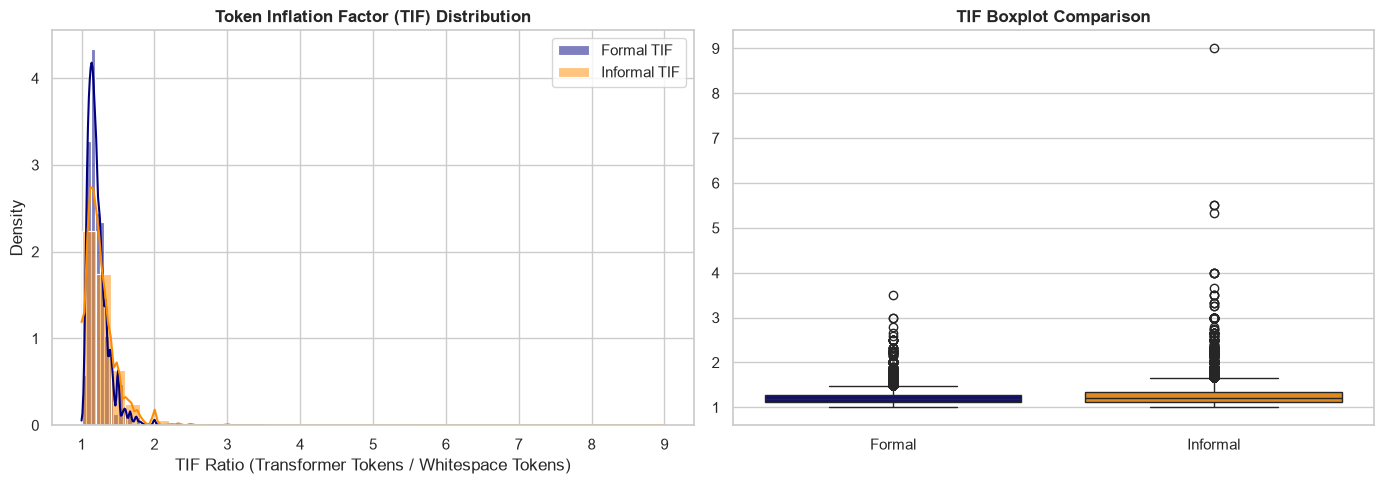

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer

def analyze_tokenization_complexity(df, model_name="HooshvareLab/bert-fa-base-uncased"):
    print(f"Loading tokenizer: {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    print("\n================ Subword Fragmentation Samples ================\n")
    sample_indices = [22949, 8671, 29288]
    
    for idx in sample_indices:
        if idx in df.index:
            formal_text = str(df.loc[idx, 'formalForm'])
            informal_text = str(df.loc[idx, 'inFormalForm'])
            
            formal_subwords = tokenizer.tokenize(formal_text)
            informal_subwords = tokenizer.tokenize(informal_text)
            
            print(f"--- Pair ID: {idx} ---")
            print(f"Formal Text:       {formal_text}")
            print(f"Formal Subwords:   {formal_subwords}\n")
            print(f"Informal Text:     {informal_text}")
            print(f"Informal Subwords: {informal_subwords}\n")
            print("-" * 65)

    df['formal_ws_count'] = df['formalForm'].astype(str).apply(lambda x: len(x.split()))
    df['informal_ws_count'] = df['inFormalForm'].astype(str).apply(lambda x: len(x.split()))
    
    df['formal_bert_count'] = df['formalForm'].astype(str).apply(lambda x: len(tokenizer.tokenize(x)))
    df['informal_bert_count'] = df['inFormalForm'].astype(str).apply(lambda x: len(tokenizer.tokenize(x)))
    
    df['formal_tif'] = df['formal_bert_count'] / df['formal_ws_count']
    df['informal_tif'] = df['informal_bert_count'] / df['informal_ws_count']
    
    tif_stats = df[['formal_tif', 'informal_tif']].describe().T[['mean', 'std', 'min', '50%', 'max']]
    tif_stats.rename(columns={'50%': 'median'}, inplace=True)
    
    print("\n================ Token Inflation Factor (TIF) Statistics ================")
    print(tif_stats.round(4))
    print("=========================================================================\n")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(df['formal_tif'], color='navy', label='Formal TIF', kde=True, ax=axes[0], stat='density', common_norm=False, bins=40)
    sns.histplot(df['informal_tif'], color='darkorange', label='Informal TIF', kde=True, ax=axes[0], stat='density', common_norm=False, bins=40)
    axes[0].set_title("Token Inflation Factor (TIF) Distribution", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("TIF Ratio (Transformer Tokens / Whitespace Tokens)")
    axes[0].legend()
    
    sns.boxplot(data=df[['formal_tif', 'informal_tif']], palette=['navy', 'darkorange'], ax=axes[1])
    axes[1].set_title("TIF Boxplot Comparison", fontsize=12, fontweight='bold')
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(['Formal', 'Informal'])
    
    plt.tight_layout()
    plt.show()
    
    return df, tokenizer

df, tokenizer = analyze_tokenization_complexity(df)

<a id="parsbert-embeddings"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">2. ParsBERT Contextual Embeddings & Sentence Representation</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #bd9f72; color: #4b3a1f;">
    <strong>📜 Methodology:</strong>
    We leverage the pre-trained transformer model <code>HooshvareLab/bert-fa-base-uncased</code>. Sentences are tokenized, and contextual embeddings are extracted from the hidden states using either the <code>[CLS]</code> token activation or a mean pooling strategy over the token length to create dense vector representations.
</div>


<a id="visualization"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">3. Dimensionality Reduction (PCA, t-SNE/UMAP) & Alignment Visualization</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #bd9f72; color: #4b3a1f;">
    <strong>📜 Methodology:</strong>
    High-dimensional sentence vectors (768 dimensions) are projected to 2D space. Linear decomposition via <code>PCA</code> is compared against non-linear manifold projections (<code>t-SNE</code> or <code>UMAP</code>). We generate scatter plots containing linked lines between corresponding formal and colloquial coordinates to evaluate spatial alignment.
</div>


<a id="classification"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">4. Balanced Binary Dataset Creation & Classification Pipeline</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #bd9f72; color: #4b3a1f;">
    <strong>📜 Methodology:</strong>
    We compile a balanced classification task using the ParsMap sentence pairs. Label <code>1</code> represents matched formal-informal pairs, while label <code>0</code> represents mismatched, randomly combined sentences. To prevent data leakage, the splits (80/10/10) are separated before cross-sentence tokenization and training.
</div>


<a id="evaluation"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">5. Comparative Analysis (Word2Vec vs. ParsBERT)</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #bd9f72; color: #4b3a1f;">
    <strong>📜 Methodology:</strong>
    We evaluate the classification boundaries using accuracy, recall, and ROC-AUC metrics. This step analyzes the limitations of static word vectors (Word2Vec) compared to deep contextual encoders (ParsBERT) in parsing Persian morphology, colloquial spelling variations, and structural changes.
</div>
